In [ ]:
import pandas as pd #importing pandas Library

df = pd.read_csv('Sentiment dataset.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Missing values in dataset:") 
print(df.isnull().sum()) #missing values

print("\nSummary Statistics:")
print(df.describe(include='all')) #summary statistics

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts()) #sentiment distribution

Missing values in dataset:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Summary Statistics:
        Unnamed: 0.1  Unnamed: 0  \
count     732.000000  732.000000   
unique           NaN         NaN   
top              NaN         NaN   
freq             NaN         NaN   
mean      366.464481  369.740437   
std       211.513936  212.428936   
min         0.000000    0.000000   
25%       183.750000  185.750000   
50%       366.500000  370.500000   
75%       549.250000  553.250000   
max       732.000000  736.000000   

                                                     Text    Sentiment  \
count                                                 732          732   
unique                                                707          279   
top      A com

Sentiment_Category
Neutral     537
Positive    167
Negative     28
Name: count, dtype: int64


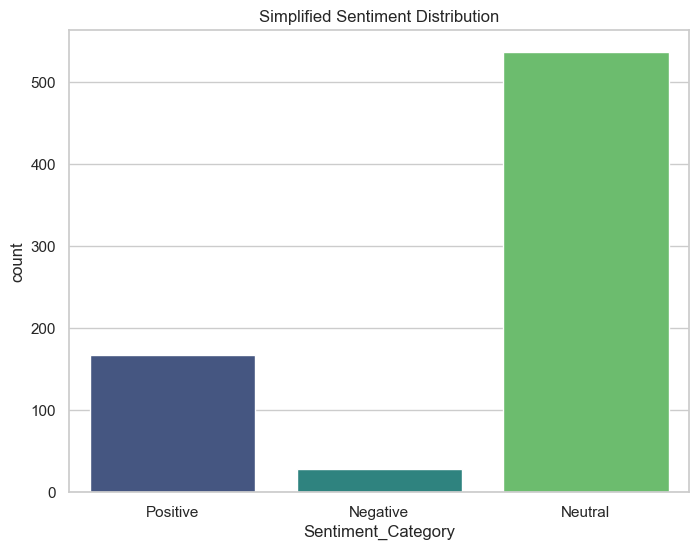

In [ ]:
#Data Simplification
def simplify_sentiment(sentiment):
  
    sentiment = str(sentiment).strip().capitalize()
    
    pos = ['Positive', 'Happiness', 'Joy', 'Love', 'Amusement', 'Enjoyment', 'Admiration', 'Affection', 'Awe', 'Acceptance', 'Adoration', 'Excitement', 'Kind']
    neg = ['Negative', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Disappointed', 'Bitter', 'Confusion']
    
    if sentiment in pos:
        return 'Positive'
    elif sentiment in neg:
        return 'Negative'
    else:
        return 'Neutral'


df['Sentiment_Category'] = df['Sentiment'].apply(simplify_sentiment)
print(df['Sentiment_Category'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=df, palette='viridis', hue='Sentiment_Category', legend=False)
plt.title('Simplified Sentiment Distribution')
plt.show() #plotting the graph of simplified sentiment distribution

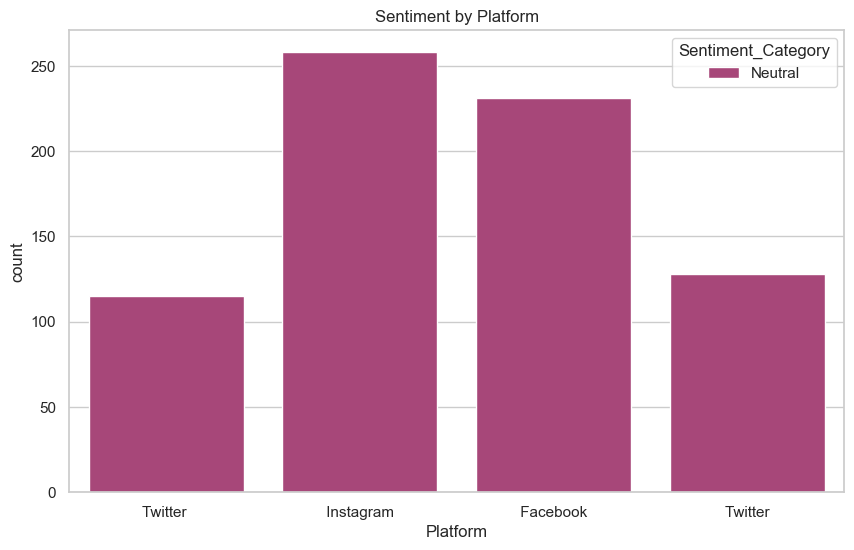

In [ ]:
#Platform-wise Plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Platform', hue='Sentiment_Category', data=df, palette='magma')
plt.title('Sentiment by Platform')
plt.show() #plotting the graph visualization of sentiment by platform

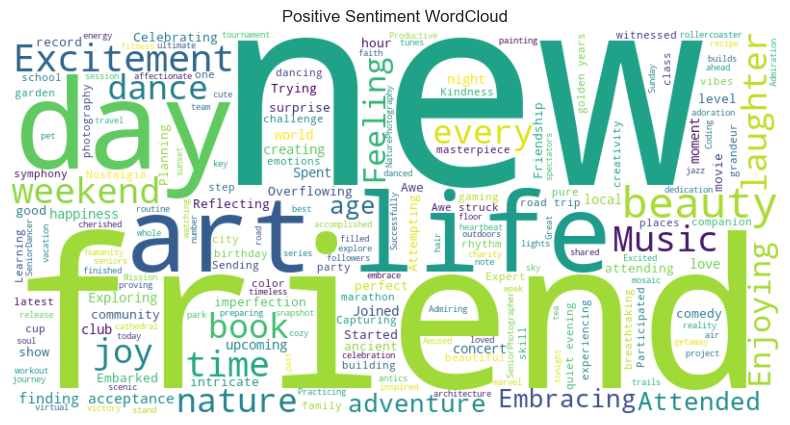

In [ ]:
#wordcloud
from wordcloud import WordCloud

pos_text = " ".join(df[df['Sentiment_Category'] == 'Positive']['Text'])
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text) #cloud of Positive words

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment WordCloud')
plt.show()

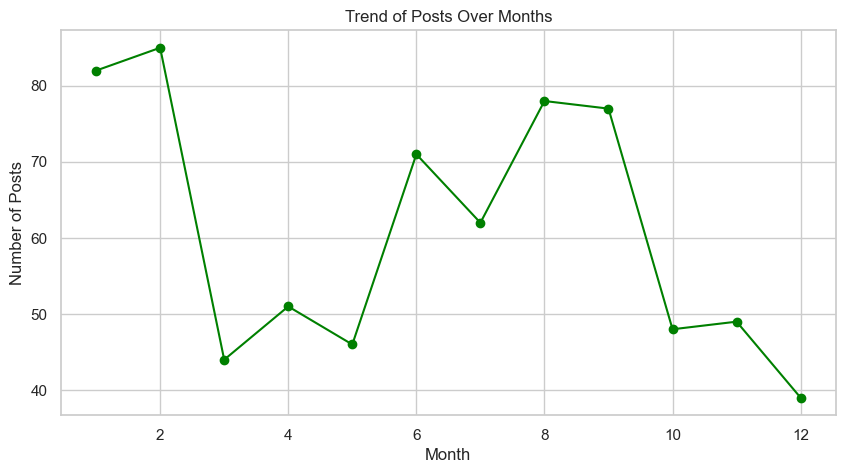

In [ ]:
# Line chart for sentiment trend over time (e.g., Months)
plt.figure(figsize=(10, 5))
df.groupby('Month').size().plot(kind='line', marker='o', color='green')
plt.title('Trend of Posts Over Months')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.savefig('Trend_Line_Chart.png', dpi=300) #trend_Line_chart.png
plt.show()

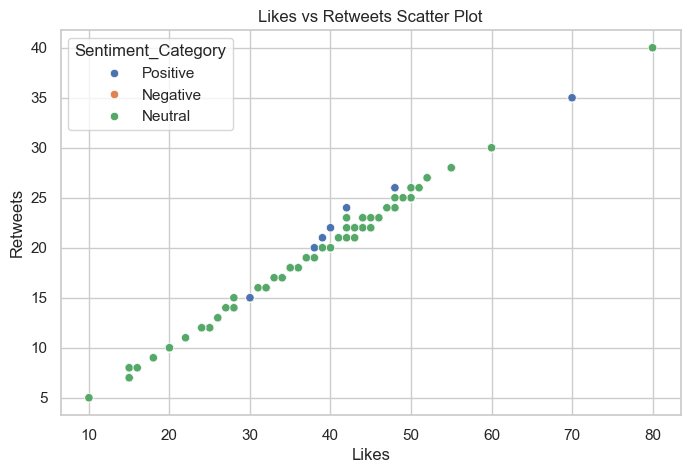

In [23]:
# Scatter plot for Likes vs Retweets
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Likes', y='Retweets', data=df, hue='Sentiment_Category')
plt.title('Likes vs Retweets Scatter Plot')
plt.savefig('Likes_Retweets_Scatter.png', dpi=300)
plt.show() #plotting the graph for likes VS retweets

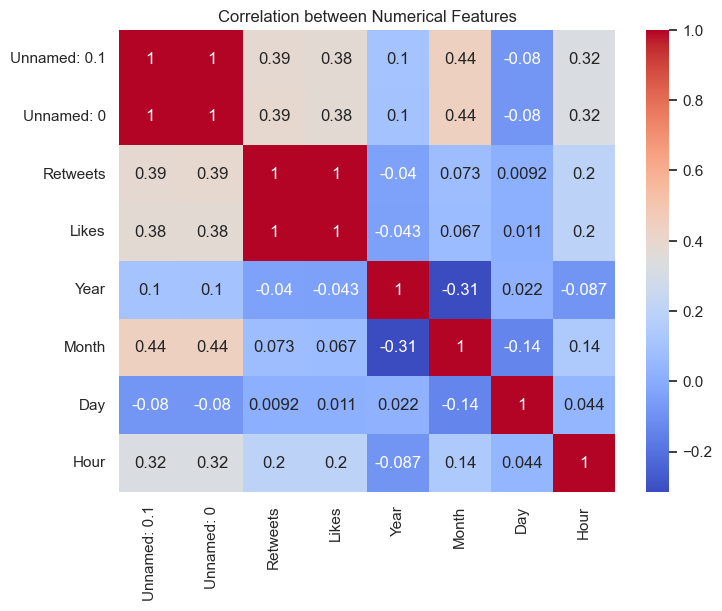

In [ ]:
#Correlation Matrix [Task 2 : correlations between numerical features]

numerical_df = df.select_dtypes(include=['int64', 'float64'])

corr = numerical_df.corr() #correlation calculation

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Numerical Features')
plt.show() #plotting heatmap

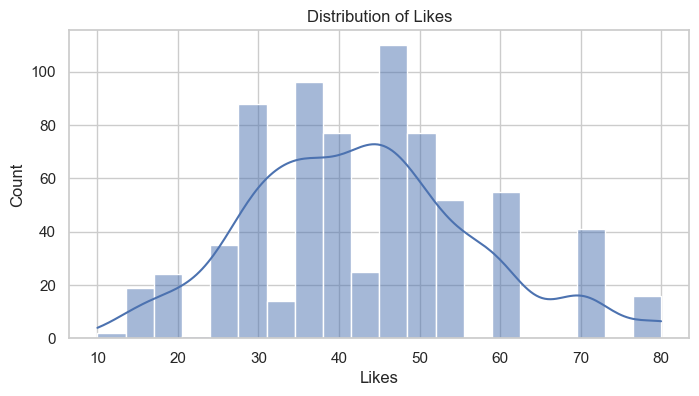

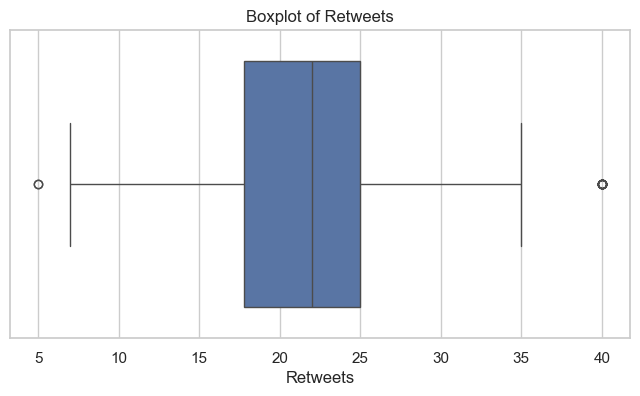

In [14]:
#Boxplot & Histogram [Level 1 - Task 2 & 3]
plt.figure(figsize=(8, 4))
sns.histplot(df['Likes'], bins=20, kde=True)
plt.title('Distribution of Likes')
plt.show() # Histogram for Likes

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Retweets'])
plt.title('Boxplot of Retweets')
plt.show() # Boxplot to find outliers in Retweets

C:\Users\joshi\AppData\Local\Temp\ipykernel_29248\3348166893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Category', data=df, palette='viridis')


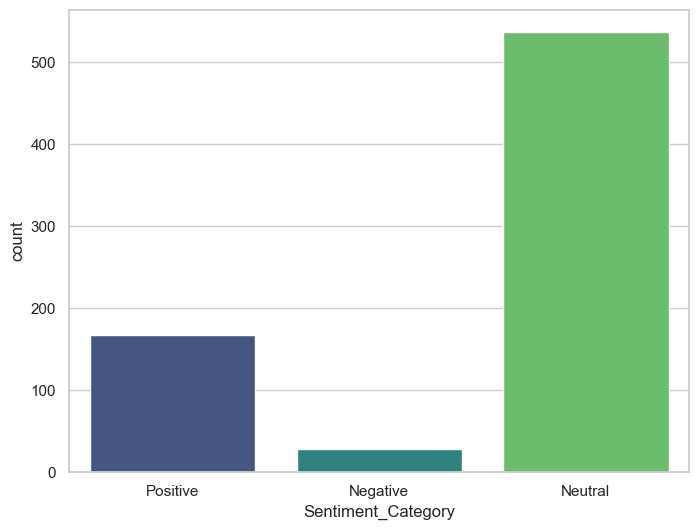

In [ ]:
#Sentiment_distribution.png
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=df, palette='viridis')

plt.savefig('sentiment_distribution.png', dpi=300) 
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_29248\3616154609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Category', data=df, palette='viridis')


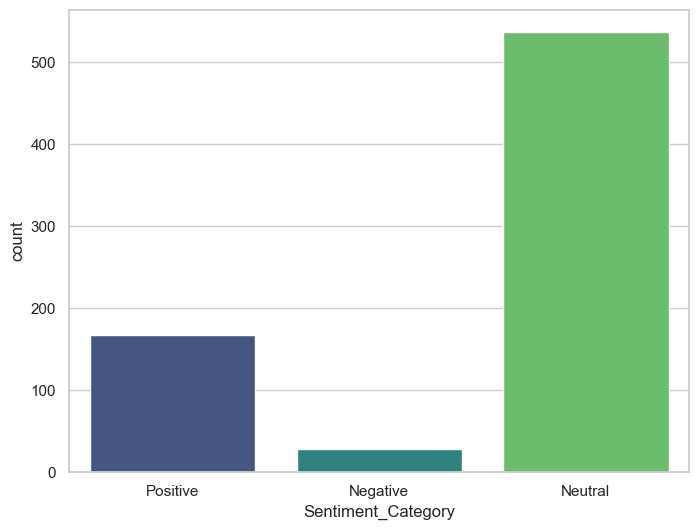

In [ ]:
#correlation matrix.png
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=df, palette='viridis')

plt.savefig('correlation matrix.png', dpi=300) 
plt.show()

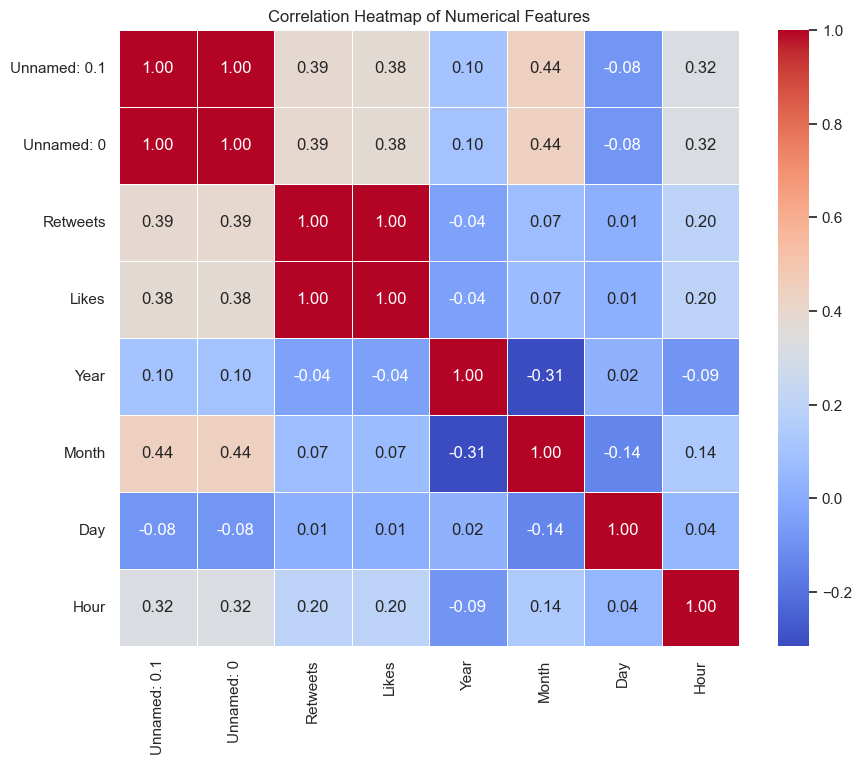

In [17]:
#savefig for correlation matrix
numerical_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_df.corr() #calculating correlation matrix

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) #plotting heatmap

plt.title('Correlation Heatmap of Numerical Features')

plt.savefig('Correlation_Heatmap.png', dpi=300)
plt.show()

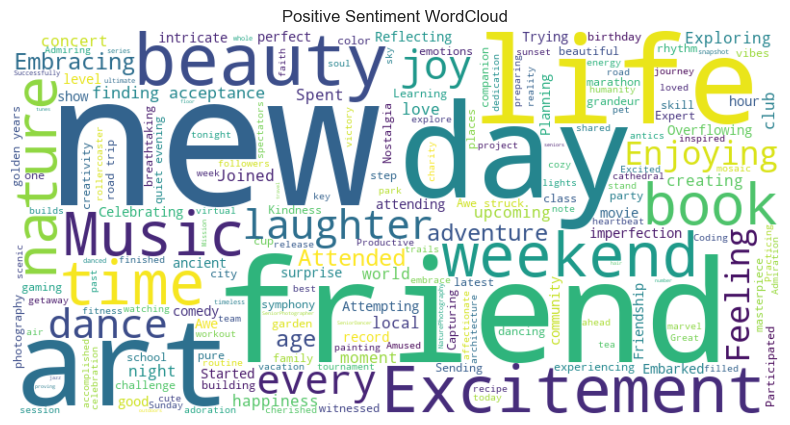

In [ ]:
#Positive_WordCloud.png
from wordcloud import WordCloud

pos_text = " ".join(df[df['Sentiment_Category'] == 'Positive']['Text']) # Positive Words WordCloud
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment WordCloud')
plt.savefig('Positive_WordCloud.png', dpi=300)
plt.show()

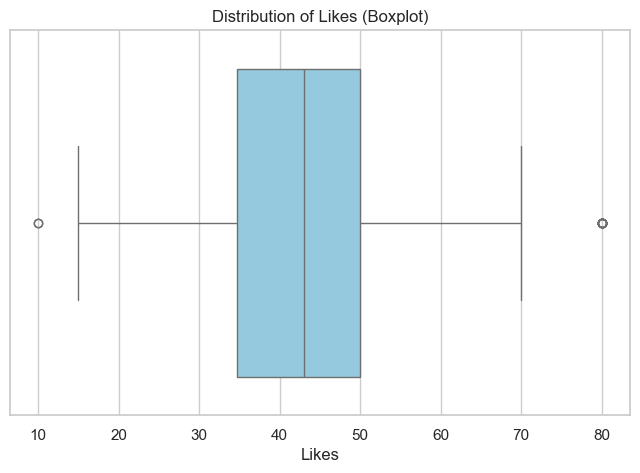

In [19]:
# Boxplot for Likes
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Likes'], color='skyblue')
plt.title('Distribution of Likes (Boxplot)')
plt.savefig('Likes_Boxplot.png', dpi=300)
plt.show()

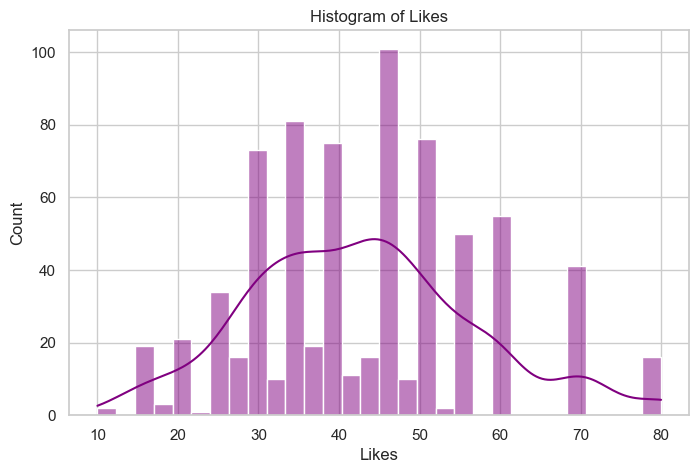

In [20]:
# Histogram for Likes
plt.figure(figsize=(8, 5))
sns.histplot(df['Likes'], bins=30, kde=True, color='purple')
plt.title('Histogram of Likes')
plt.savefig('Likes_Histogram.png', dpi=300)
plt.show()

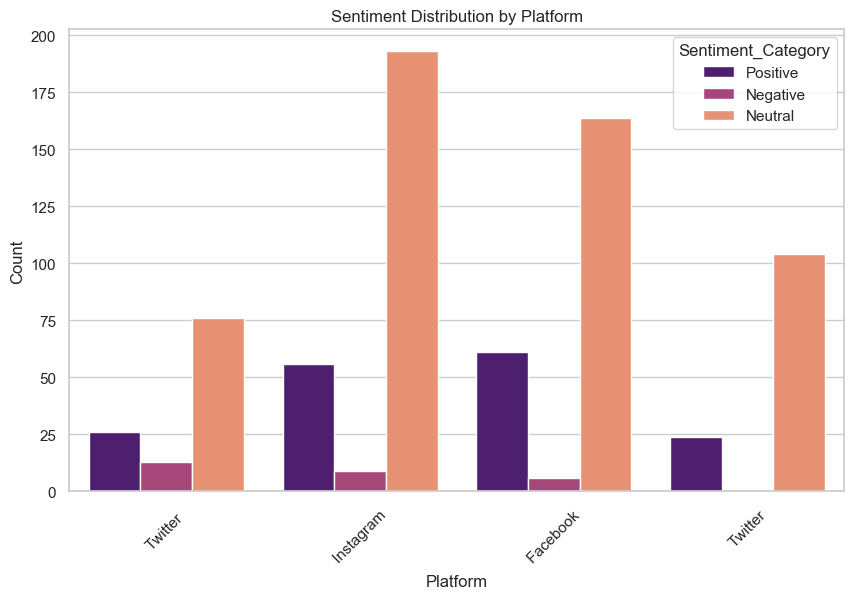

In [ ]:
#Platform_Sentiment.png
plt.figure(figsize=(10, 6))
sns.countplot(x='Platform', hue='Sentiment_Category', data=df, palette='magma')

plt.title('Sentiment Distribution by Platform') # Platform-wise Sentiment Analysis
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.savefig('Platform_Sentiment.png', dpi=300)
plt.show()